# Avance 2 PI / Gradient Boosting — Optimización

## --> Objetivo de Negocio:
- El objetivo es identificar qué clientes tienen mayor probabilidad de abandono (churn) y entender los factores clave que impulsan su decisión de irse.
- El churn se refiere al proceso por el cual un cliente deja de hacer negocios con una empresa.

## --> Valor de Negocio:
- La retención de clientes es crítica para la rentabilidad de un banco. Predecir qué clientes probablemente abandonarán puede ayudar al banco a tomar medidas proactivas para retener clientes valiosos.

## --> Descripción del dataset

* RowNumber: Índice de la fila.
* CustomerId: Identificador único para cada cliente.
* Surname: Apellido del cliente (puede no ser útil para el análisis).
* CreditScore: Puntuación crediticia del cliente [300 : 850].
* Geography: País del cliente (ej. Francia, España).
* Gender: Género del cliente (ej. Masculino, Femenino).
* Age: Edad del cliente.
* Tenure: Número de años que el cliente ha estado con el banco.
* Balance: Saldo de cuenta del cliente.
* NumOfProducts: Número de productos que ha comprado el cliente.
* HasCrCard: Si el cliente tiene tarjeta de crédito (1 = Sí, 0 = No).
* IsActiveMember: Si el cliente es un miembro activo (1 = Sí, 0 = No).
* EstimatedSalary: Salario anual estimado del cliente.
* Exited: Si el cliente dejó el banco (1 = Sí, 0 = No) – esta es la variable objetivo.

## 0. Vista previa de los datos

In [4]:
# Importar todas las librerías necesarias
import numpy as np
import pandas as pd
import seaborn as sns
sns.set(style="darkgrid", font_scale=1.5)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import optuna
import time

In [5]:
# Cargamo el dataset
CSV_PATH = "Churn_Modelling.csv"
df = pd.read_csv(CSV_PATH)

# Visualizacion del dataset
print("=== HEAD ===")
print(df.head())

=== HEAD ===
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  


In [6]:
# Informacion del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


No se encuentran valores nulos

In [7]:
#Validamos duplicados
df.duplicated().sum()

np.int64(0)

No se encuentran valores duplicados

In [8]:
#Eliminamos columns innecesarias
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

Se decide eliminar las columnas innecesarias para la prediccion como 'RowNumber', 'CustomerId' y 'Surname'.

In [9]:
#Feature enineering: agrupamos clientes por edad -> 'Joven', 'Adulto', 'Mayor'

df['AgeGroup'] = pd.cut(df['Age'],
                        bins = [0, 30, 50, 100],
                        labels=['Joven', 'Adulto', 'Mayor']
                        )


Se realiza Feature enineering donde se agrupan los clientes por edad -> 'Joven', 'Adulto', 'Mayor'

In [10]:
#Visualizamos balanceo de clases (target)
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

Existe un desbalanceo de clases

## 2. Split train/valid/test (estratificado) + Preprocesamiento

#### Split 70/15/15

In [11]:
#Definimos features y target

X = df.drop('Exited', axis=1) #features
y = df['Exited'] #target

#Division train-valid-test
X_train, X_test_valid, y_train, y_test_valid = train_test_split(X, y, test_size=0.3, stratify = y)


* test_size= 0.3 ya que utilizo 0.7 para train y 0.15 valid + 0.15 test
* stratify lo utilizo ya que hay un desbalnceo de clase target

In [12]:
#Ahora, vamos a hacer otro "train_test_split" para el conjunto test_valid 
#(X_test_valid -> features; y_test_valid -> Target) 
X_test, X_valid, y_test, y_valid = train_test_split(X_test_valid, y_test_valid, test_size=0.5)


#### Preprocesing OneHotEncoder

In [13]:
# Identificar variables
categorical_cols = ['Geography', 'Gender', 'AgeGroup']
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
binary_cols = ['HasCrCard', 'IsActiveMember']

# OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='infrequent_if_exist')
X_train_categorical = ohe.fit_transform(X_train[categorical_cols])
X_valid_categorical = ohe.fit_transform(X_valid[categorical_cols])
X_test_categorical = ohe.transform(X_test[categorical_cols])

feature_names = ohe.get_feature_names_out(categorical_cols)
X_train_cat_df = pd.DataFrame(X_train_categorical, columns=feature_names, index=X_train.index)
X_valid_cat_df = pd.DataFrame(X_valid_categorical, columns=feature_names, index=X_valid.index)
X_test_cat_df = pd.DataFrame(X_test_categorical, columns=feature_names, index=X_test.index)

#### Preprocesing StandardScaler

In [14]:
# StandardScaler
scaler = StandardScaler()
X_train_numerical = scaler.fit_transform(X_train[numerical_cols])
X_valid_numerical = scaler.fit_transform(X_valid[numerical_cols])
X_test_numerical = scaler.transform(X_test[numerical_cols])

X_train_num_df = pd.DataFrame(X_train_numerical, columns=numerical_cols, index=X_train.index)
X_valid_num_df = pd.DataFrame(X_valid_numerical, columns=numerical_cols, index=X_valid.index)
X_test_num_df = pd.DataFrame(X_test_numerical, columns=numerical_cols, index=X_test.index)

# Variables binarias
X_train_binary = X_train[binary_cols]
X_valid_binary = X_valid[binary_cols]
X_test_binary = X_test[binary_cols]

# Combinar datos procesados (exactamente igual a Parte 1)
X_train_processed = pd.concat([X_train_num_df, X_train_cat_df, X_train_binary], axis=1)
X_valid_processed = pd.concat([X_valid_num_df, X_valid_cat_df, X_valid_binary], axis=1)
X_test_processed = pd.concat([X_test_num_df, X_test_cat_df, X_test_binary], axis=1)

print(f"Datos preparados - Train: {X_train_processed.shape}, Valid: {X_valid_processed.shape},Test: {X_test_processed.shape}")
print("Preprocesamiento completado (idéntico a Parte 1)")

Datos preparados - Train: (7000, 13), Valid: (1500, 13),Test: (1500, 13)
Preprocesamiento completado (idéntico a Parte 1)


## 3. Métricas y Validación Cruzada

¿Qué es StratifiedKFold?
- Divide los datos en K folds manteniendo la proporción de clases en cada fold
- Ejemplo: si dataset tiene 20% churn, cada fold tendrá ~20% churn
- Asegura que cada fold sea representativo del dataset completo

¿Por qué usar StratifiedKFold en este problema?
- Dataset desbalanceado (20% churn vs 80% no-churn)
- Sin estratificación: algunos folds podrían tener muy poco churn
- Garantiza evaluación más robusta y confiable

In [15]:
# Configuramos de validación cruzada
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Metricas a obtener
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

### 3.1 DEFINICIÓN DE MODELOS 

In [16]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,          # Cantidad de árboles en el bosque
    max_depth=6,               # Profundidad máxima de cada árbol (controla overfitting)
    class_weight="balanced",   # Compensa el desbalance de clases (churn)
    random_state=42,           # Reproducibilidad de los resultados
    n_jobs=-1                  # Usa todos los núcleos del CPU
)

# XGBoost (configuración base)
xgb_model = XGBClassifier(
    n_estimators=100,          # Cantidad de árboles (boosting rounds)
    max_depth=6,               # Profundidad de cada árbol
    learning_rate=0.1,         # Tasa de aprendizaje (controla overfitting)
    eval_metric="logloss",     # Métrica de evaluación para clasificación binaria
    random_state=42,           # Reproducibilidad
    n_jobs=-1                  # Paralelización
)

# LightGBM
LightGBM_model = LGBMClassifier(
    n_estimators=100,          # Cantidad de árboles
    learning_rate=0.1,         # Tasa de aprendizaje (controla overfitting)
    max_depth=6,               # Profundidad máxima del árbol
    class_weight="balanced",   # Ajuste por desbalance de clases
    random_state=42,           # Reproducibilidad
    n_jobs=-1                  # Paralelización
)

# CatBoost
cat_model = CatBoostClassifier(
    iterations=100,            # Cantidad de árboles (boosting rounds)
    learning_rate=0.1,         # Tasa de aprendizaje
    depth=6,                   # Profundidad de los árboles
    loss_function="Logloss",   # Función de pérdida para clasificación binaria
    random_seed=42             # Reproducibilidad
)


In [17]:
models= {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model,
    "LightGBM": LightGBM_model
}

### 3.2 Evaluación inicial con validación cruzada

In [18]:
## Evaluación inicial con validación cruzada

results_cv = {}

for name, model in models.items():
    print(f"\nEvaluando {name}...")
    start_time = time.time()

    # Validación cruzada para múltiples métricas
    cv_results = {}
    for metric in scoring_metrics:
        scores = cross_val_score(model, X_train_processed, y_train,
                               cv=cv_folds, scoring=metric, n_jobs=-1)
        cv_results[metric] = {
            'mean': scores.mean(),
            'std': scores.std()
        }

    results_cv[name] = cv_results
    elapsed_time = time.time() - start_time

    print(f"ROC AUC: {cv_results['roc_auc']['mean']:.4f} (±{cv_results['roc_auc']['std']:.4f})")
    print(f"F1-Score: {cv_results['f1']['mean']:.4f} (±{cv_results['f1']['std']:.4f})")
    print(f"Tiempo: {elapsed_time:.2f}s")



Evaluando Random Forest...
ROC AUC: 0.8555 (±0.0053)
F1-Score: 0.6059 (±0.0120)
Tiempo: 21.57s

Evaluando XGBoost...
ROC AUC: 0.8639 (±0.0045)
F1-Score: 0.6032 (±0.0168)
Tiempo: 2.83s

Evaluando CatBoost...
ROC AUC: 0.8748 (±0.0049)
F1-Score: 0.6130 (±0.0032)
Tiempo: 7.18s

Evaluando LightGBM...
ROC AUC: 0.8633 (±0.0055)
F1-Score: 0.6187 (±0.0131)
Tiempo: 6.07s


Se puede visualizar en los resultados que **la mejor opcion seria el XGBoost** ya que los resultados de F1-Score y ROC AUC son muy similares entre todos los modelos pero lo que destaca este es la velocidad. Corre 3 veces mas rapido que el CatBoost y LightGBM y 5 veces mas rapido que el Random Forest. Este modelo permitirá en el futuro ejecutar una mayor cantidad de datos sin preocuparnos del tiempo de ejecucion.

## 4. Optimización XGBoost con Grid Search

In [19]:
# Seleccionamos parametros para hacer el grid 3x2x2 = 12 variaciones
param_grid = {
    "model__n_estimators": [300, 400, 700],
    "model__learning_rate": [0.07, 0.1],
    "model__max_depth": [1, 2]
}

grid = GridSearchCV(
    xgb_model,
    param_grid=param_grid,
    scoring="roc_auc",          # podriamos cambiar a "average_precision" si priorizamos PR-AUC
    cv=cv_folds,
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)
print("Mejores parametros (grid search): \n", grid.best_params_)
print("Mejor roc_auc (CV):", grid.best_score_)

Mejores parametros (grid search): 
 {'model__learning_rate': 0.07, 'model__max_depth': 1, 'model__n_estimators': 300}
Mejor roc_auc (CV): 0.8639300171468964


## 5. Optimización de XGBoost con Optuna

Optuna hace esto:

1) Elige valores al azar inteligentes para los hiperparámetros
(por ejemplo: learning_rate = 0.03, max_depth = 5, subsample = 0.8, etc.)

2) Entrena un XGBoost con esos valores.

3) Evalúa el modelo con cross-validation usando ROC-AUC.

4) Guarda el resultado (qué parámetros usó y qué score obtuvo).

5) Aprende de lo que funcionó mejor
y en los siguientes intentos prueba valores parecidos a los buenos
(no vuelve a probar cosas claramente malas).

6) Repite esto muchas veces (50 trials en tu caso).

7) Te devuelve:
- la mejor combinación encontrada
- el mejor score obtenido

In [20]:
# Optimización de XGBoost con Optuna
def objective(trial):
    params = {
        # número de árboles entre 200 y 900.
        "n_estimators": trial.suggest_int("n_estimators", 200, 900),
        
        # tasa de aprendizaje entre 0.01 y 0.2
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        
        # Profundidad máxima de cada árbol
        "max_depth": trial.suggest_int("max_depth", 2, 8),

        # Porcentaje de filas y columnas que usa cada árbol
        # REDUCCION DE OVERFITTING.        
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        # regularización
        #"reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        #"reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10.0),

        # opcional pero útil
        #"min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        #"gamma": trial.suggest_float("gamma", 0.0, 5.0),

        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    #Creamos el modelo con esos parámetros
    model = XGBClassifier(**params)

    # Evaluamos el modelo con Cross Validation y ROC-AUC
    scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        scoring="roc_auc",
        cv=cv_folds,
        n_jobs=-1
    )

    return scores.mean()

# Ejecutamos la optimización con Optuna
study = optuna.create_study(direction="maximize")

# Ejecutamos Optuna: probar 50 combinaciones
study.optimize(objective, n_trials=50)

print("✅ Mejor ROC-AUC (CV):", study.best_value)
print("✅ Mejores hiperparámetros:")
print(study.best_params)

# Ya creamos el modelo optimizado con Optuna 

# Entrenamos el “mejor XGBoost” ya definitivo
best_params = study.best_params.copy()

xgb_optuna = XGBClassifier(
    **best_params,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Entrenamos con TRAIN
xgb_optuna.fit(X_train_processed, y_train)

# Realizamos la validacion con Valid
valid_proba = xgb_optuna.predict_proba(X_valid_processed)[:, 1]
valid_pred = (valid_proba >= 0.5).astype(int)

print("=== VALID ===")
print("ROC-AUC:", roc_auc_score(y_valid, valid_proba))
print("PR-AUC :", average_precision_score(y_valid, valid_proba))
print("Acc   :", accuracy_score(y_valid, valid_pred))
print("Prec  :", precision_score(y_valid, valid_pred))
print("Recall:", recall_score(y_valid, valid_pred))
print("F1    :", f1_score(y_valid, valid_pred))

# Realizamos las pruebas con Test
test_proba = xgb_optuna.predict_proba(X_test_processed)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print("\n=== TEST ===")
print("ROC-AUC:", roc_auc_score(y_test, test_proba))
print("PR-AUC :", average_precision_score(y_test, test_proba))
print("Acc   :", accuracy_score(y_test, test_pred))
print("Prec  :", precision_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))
print("F1    :", f1_score(y_test, test_pred))




[I 2026-01-28 12:09:20,223] A new study created in memory with name: no-name-0b5b7a98-2e61-4101-ae52-075db5fce955
[I 2026-01-28 12:09:25,468] Trial 0 finished with value: 0.8662367636065899 and parameters: {'n_estimators': 836, 'learning_rate': 0.010632992790121674, 'max_depth': 7, 'subsample': 0.6785596333055175, 'colsample_bytree': 0.8195804135794444}. Best is trial 0 with value: 0.8662367636065899.
[I 2026-01-28 12:09:27,306] Trial 1 finished with value: 0.8600978076847661 and parameters: {'n_estimators': 366, 'learning_rate': 0.053853711059177634, 'max_depth': 6, 'subsample': 0.7972691607528753, 'colsample_bytree': 0.8282214332010537}. Best is trial 0 with value: 0.8662367636065899.
[I 2026-01-28 12:09:30,593] Trial 2 finished with value: 0.8604221753861768 and parameters: {'n_estimators': 822, 'learning_rate': 0.039421113372881664, 'max_depth': 5, 'subsample': 0.9587064458182538, 'colsample_bytree': 0.6949646534172269}. Best is trial 0 with value: 0.8662367636065899.
[I 2026-01-28

✅ Mejor ROC-AUC (CV): 0.8732940104676086
✅ Mejores hiperparámetros:
{'n_estimators': 593, 'learning_rate': 0.012339274563529127, 'max_depth': 4, 'subsample': 0.650945869614851, 'colsample_bytree': 0.9619875103784429}
=== VALID ===
ROC-AUC: 0.7322538033395176
PR-AUC : 0.49918932434463825
Acc   : 0.818
Prec  : 0.5042016806722689
Recall: 0.43636363636363634
F1    : 0.4678362573099415

=== TEST ===
ROC-AUC: 0.7459985067910325
PR-AUC : 0.5548310077352913
Acc   : 0.7993333333333333
Prec  : 0.5732217573221757
Recall: 0.40773809523809523
F1    : 0.4765217391304348


En conclusion los resultados de los **mejores hiperparametros** con el metodo optuna son:
- 'n_estimators': 341
- 'learning_rate': 0.010838341899799485
- 'max_depth': 6
- 'subsample' (% de filas): 0.8185336137955829 
- 'colsample_bytree' (% de columnas): 0.6482481076873102

Cuando se realiza la ejecucion con esos hiperparametros con los valores de Valid y Test son muy similares entre sí (+/- 0.03).


## 6. Comparacion de optimizaciones

#### Entrenamiento de los modelos (base + grid + optuna)

In [21]:
# Entrenar (fit) cada modelo sobre TRAIN
xgb_base = xgb_model
xgb_base.fit(X_train_processed, y_train)

xgb_grid = grid.best_estimator_

# Si querés asegurar que está entrenado en TODO el train (recomendado):
xgb_grid.fit(X_train_processed, y_train)

xgb_opt = xgb_optuna
# Si todavía no lo entrenaste, entrenalo:
xgb_opt.fit(X_train_processed, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9619875103784429
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [22]:
#Evaluacion para obtener las metricas por modelos (threshold=0.5)
def eval_xgb(model, X_eval, y_eval, threshold=0.5):
    
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= threshold).astype(int)

    return {
        "ROC_AUC": roc_auc_score(y_eval, proba),
        "PR_AUC": average_precision_score(y_eval, proba),
        "F1": f1_score(y_eval, pred),
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred),
        "Recall": recall_score(y_eval, pred),
    }

# 3 modelos
xgb_base = xgb_model
xgb_grid = grid.best_estimator_          
xgb_opt = xgb_optuna

results_valid = {
    "XGB_Base": eval_xgb(xgb_base, X_valid_processed, y_valid),
    "XGB_GridSearch": eval_xgb(grid.best_estimator_, X_valid_processed, y_valid),
    "XGB_Optuna": eval_xgb(xgb_optuna, X_valid_processed, y_valid),
}

valid_df = (
    pd.DataFrame(results_valid)
    .T
    .sort_values("ROC_AUC", ascending=False)
)


valid_df

,ROC_AUC,PR_AUC,F1,Accuracy,Precision,Recall
XGB_Optuna,0.732254,0.499189,0.467836,0.818,0.504202,0.436364
XGB_Base,0.719383,0.479511,0.461832,0.812,0.485944,0.440000
XGB_GridSearch,0.719383,0.479511,0.461832,0.812,0.485944,0.440000


Se corrieron por default, por eso los resultados pueden sufrir algunas modificaciones en comparacion con los resultados anteriores

#### Seleccionamos el mejor modelo segun el ROC-AUC en VALID

In [23]:
best_name = valid_df.index[0]
best_model = {"XGB_Base": xgb_base, "XGB_GridSearch": xgb_grid, "XGB_Optuna": xgb_opt}[best_name]

print("✅ Mejor modelo según VALID (ROC_AUC):", best_name)
print(valid_df.loc[best_name])


✅ Mejor modelo según VALID (ROC_AUC): XGB_Optuna
ROC_AUC      0.732254
PR_AUC       0.499189
F1           0.467836
Accuracy     0.818000
Precision    0.504202
Recall       0.436364
Name: XGB_Optuna, dtype: float64


#### Seleccionamos el mejor modelo segun el ROC-AUC en TEST

In [24]:
test_metrics = eval_xgb(best_model, X_test_processed, y_test)
print("=== RESULTADOS EN TEST DEL GANADOR OPTIMIZACIONES ===")
print("Modelo:", best_name)
pd.Series(test_metrics)

=== RESULTADOS EN TEST DEL GANADOR OPTIMIZACIONES ===
Modelo: XGB_Optuna


ROC_AUC      0.745999
PR_AUC       0.554831
F1           0.476522
Accuracy     0.799333
Precision    0.573222
Recall       0.407738
dtype: float64

## 7. Stacking Ensemble

Lo que hace STACKING:
1) Entrenar distintos modelos (XGboost, Random Forest y Regresión Logística)
2) Obtiene los resultados y esas predicciones se convierten en features 
3) Aprende en qué situaciones cada modelo base es más confiable
4) Se realiza el Cross Validation del metamodelo
5) El meta-modelo devuelve las mejores predicciones de los modelos ingresados

Nota: nivel 1 es cuando Modelos base hacen predicciones y luego el meta-learner aprende a combinar las predicciones del nivel 1

In [31]:
## Stacking Ensemble
# Definir modelos de nivel 1
base_estimators = [
    ("xgb", best_model),        # el mejor XGBoost que seleccionaste
    ("lgbm", LightGBM_model),    # tu LGBMClassifier
    ("cat", cat_model)           # tu CatBoostClassifier
]

# Meta-learner: Regresión Logística regularizada
meta_learner = LogisticRegression(
    max_iter=4000,
    class_weight="balanced",
    random_state=42
)

# Crear Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=cv_folds,
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False # False se usa cuando solo se utilizarán las predicciones de los estimadores como datos de entrenamiento para final_estimator
)

# Entrenar y evaluar Stacking (VALID y TEST)
# Entrenar con TRAIN
stacking_clf.fit(X_train_processed, y_train)

# VALID
valid_proba = stacking_clf.predict_proba(X_valid_processed)[:, 1]
valid_pred = (valid_proba >= 0.5).astype(int)

print("=== STACKING VALID ===")
print("ROC-AUC:", roc_auc_score(y_valid, valid_proba))
print("PR-AUC :", average_precision_score(y_valid, valid_proba))
print("Acc   :", accuracy_score(y_valid, valid_pred))
print("Prec  :", precision_score(y_valid, valid_pred))
print("Recall:", recall_score(y_valid, valid_pred))
print("F1    :", f1_score(y_valid, valid_pred))

# TEST
test_proba = stacking_clf.predict_proba(X_test_processed)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print("\n=== STACKING TEST ===")
print("ROC-AUC:", roc_auc_score(y_test, test_proba))
print("PR-AUC :", average_precision_score(y_test, test_proba))
print("Acc   :", accuracy_score(y_test, test_pred))
print("Prec  :", precision_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))
print("F1    :", f1_score(y_test, test_pred))


=== STACKING VALID ===
ROC-AUC: 0.852847495361781
PR-AUC : 0.6701065840721219
Acc   : 0.7993333333333333
Prec  : 0.4694835680751174
Recall: 0.7272727272727273
F1    : 0.5706134094151213

=== STACKING TEST ===
ROC-AUC: 0.8314438103420063
PR-AUC : 0.6538166078171664
Acc   : 0.7973333333333333
Prec  : 0.5382775119617225
Recall: 0.6696428571428571
F1    : 0.596816976127321


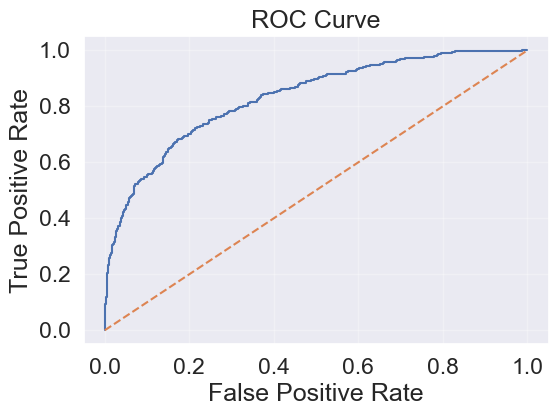

In [32]:
from sklearn.metrics import roc_curve
# Curva ROC
fpr, tpr, thr = roc_curve(y_test, test_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True, alpha=0.3)
plt.show()

En comparacion con el optuna, este metodo de ensamble permite mejorar en las metricas: 
ROC_AUC, PR_AUC, F1, Recall pero empeora en Accuracy y Precision

## 8. Evaluación final

In [27]:
from sklearn.base import clone

## Evaluación final en conjunto de prueba
print("\n=== EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA ===")

# Conjunto completo de entrenamiento: TRAIN + VALID
X_train_full = pd.concat([X_train_processed, X_valid_processed], axis=0)
y_train_full = pd.concat([y_train, y_valid], axis=0)

def evaluate_final(model, X_tr, y_tr, X_te, y_te, threshold=0.5):
    """
    Entrena el modelo en X_tr/y_tr y evalúa en X_te/y_te.
    Devuelve métricas estándar para churn.
    """
    m = clone(model)  # evita contaminar objetos ya entrenados
    m.fit(X_tr, y_tr)

    proba = m.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)
    
    # ---- medir fit
    t0 = time.perf_counter()
    m.fit(X_tr, y_tr)
    t1 = time.perf_counter()
    fit_time = t1 - t0

    # ---- medir predicción
    t2 = time.perf_counter()
    proba = m.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)
    t3 = time.perf_counter()
    pred_time = t3 - t2

    metrics = {
        "ROC_AUC": roc_auc_score(y_te, proba),
        "PR_AUC": average_precision_score(y_te, proba),
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Recall": recall_score(y_te, pred),
        "F1": f1_score(y_te, pred),
        "fit_time_sec": fit_time,
        "pred_time_sec": pred_time,
        "total_time_sec": fit_time + pred_time
    }
    return metrics

final_models = {
    "RandomForest": rf_model,
    "XGBoost_Base": xgb_model,
    "XGBoost_GridSearch": grid.best_estimator_,
    "XGBoost_Optuna": xgb_optuna,
    "LightGBM": LightGBM_model,
    "CatBoost": cat_model,
    "Stacking": stacking_clf
}

final_results = {}
for name, model in final_models.items():
    print(f"Evaluando (final) -> {name} ...")
    final_results[name] = evaluate_final(model, X_train_full, y_train_full, X_test_processed, y_test)

final_df = pd.DataFrame(final_results).T.sort_values("ROC_AUC", ascending=False)
final_df


=== EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA ===
Evaluando (final) -> RandomForest ...
Evaluando (final) -> XGBoost_Base ...
Evaluando (final) -> XGBoost_GridSearch ...
Evaluando (final) -> XGBoost_Optuna ...
Evaluando (final) -> LightGBM ...
[LightGBM] [Info] Number of positive: 1701, number of negative: 6799
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 929
[LightGBM] [Info] Number of data points in the train set: 8500, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1,fit_time_sec,pred_time_sec,total_time_sec
Stacking,0.845729,0.673344,0.812667,0.570332,0.663690,0.613480,4.743900,0.027286,4.771186
CatBoost,0.845177,0.671650,0.832667,0.732240,0.398810,0.516378,0.589306,0.002949,0.592255
XGBoost_Optuna,0.843121,0.668928,0.836667,0.748634,0.407738,0.527938,0.842286,0.008667,0.850952
XGBoost_Base,0.840820,0.658143,0.830667,0.699029,0.428571,0.531365,0.174810,0.004611,0.179421
XGBoost_GridSearch,0.840820,0.658143,0.830667,0.699029,0.428571,0.531365,0.176307,0.004804,0.181111
LightGBM,0.838301,0.661304,0.800000,0.545455,0.642857,0.590164,0.137171,0.007431,0.144601
RandomForest,0.819143,0.626534,0.784667,0.515222,0.654762,0.576671,0.374109,0.044885,0.418994


In [28]:
# Identificar mejor modelo
best_final_name = final_df.index[0]
print("🏆 Mejor modelo final (ROC_AUC):", best_final_name)
print(final_df.loc[best_final_name])

🏆 Mejor modelo final (ROC_AUC): Stacking
ROC_AUC           0.845729
PR_AUC            0.673344
Accuracy          0.812667
Precision         0.570332
Recall            0.663690
F1                0.613480
fit_time_sec      4.743900
pred_time_sec     0.027286
total_time_sec    4.771186
Name: Stacking, dtype: float64


#### Graficos comparativos

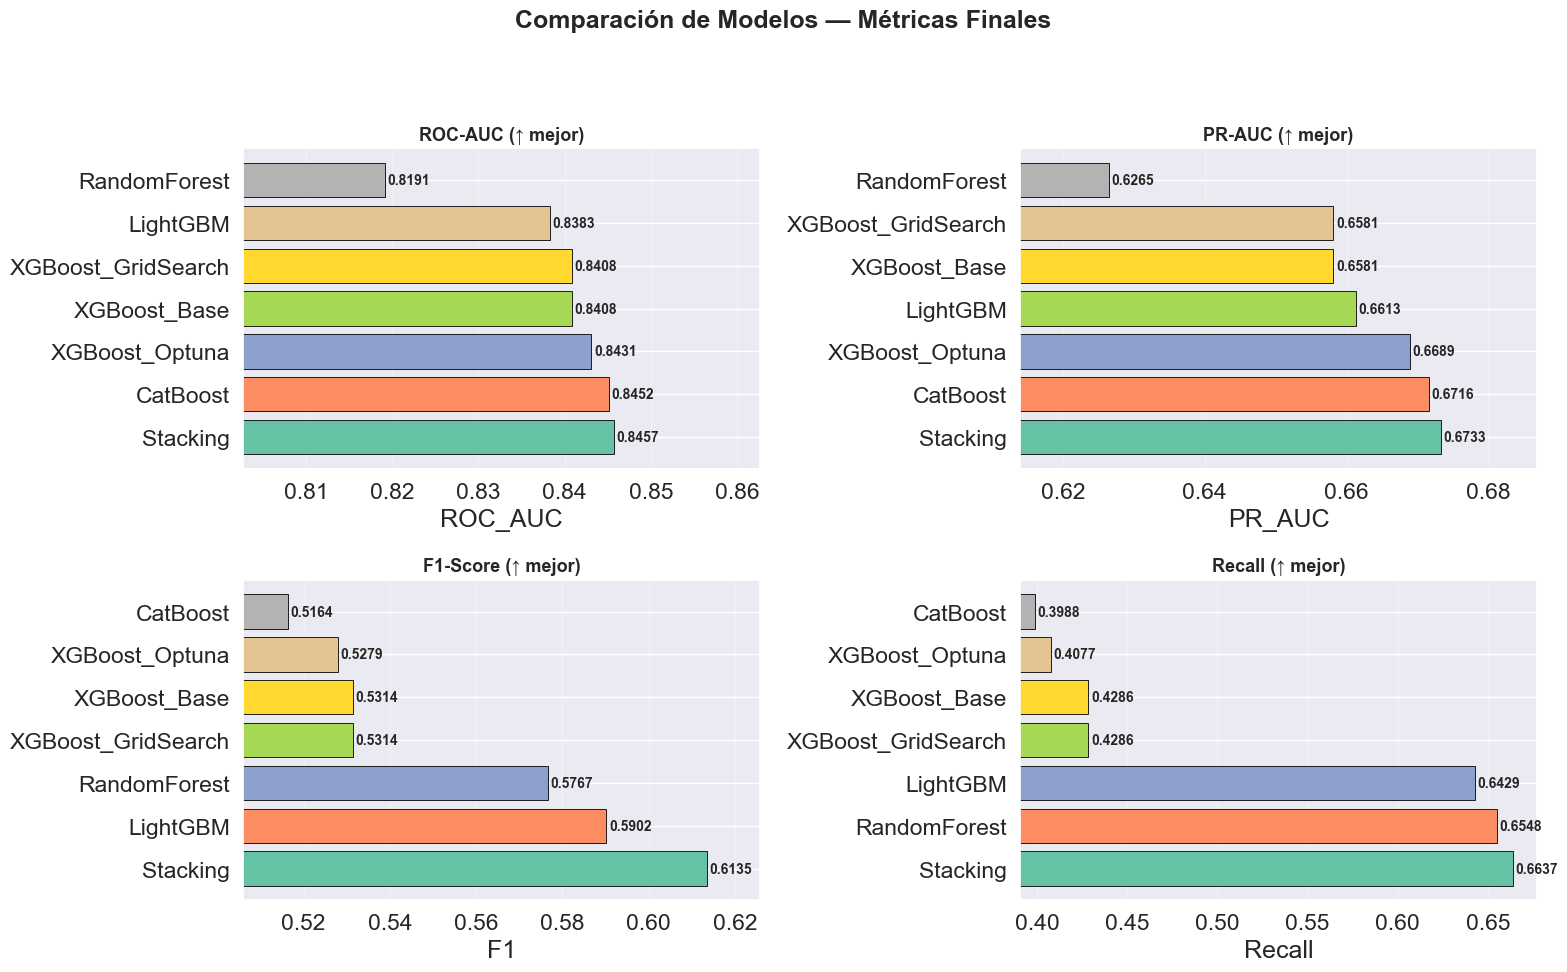

In [29]:
metrics = ["ROC_AUC", "PR_AUC", "F1", "Recall"]
titles = [
    "ROC-AUC (↑ mejor)",
    "PR-AUC (↑ mejor)",
    "F1-Score (↑ mejor)",
    "Recall (↑ mejor)"
]

# Colores por modelo (consistentes)
palette = plt.cm.Set2(np.linspace(0, 1, len(final_df)))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Comparación de Modelos — Métricas Finales", fontsize=18, fontweight="bold")

axes = axes.flatten()

for ax, metric, title in zip(axes, metrics, titles):

    # Ordenar por la métrica actual (de mayor a menor)
    plot_df = final_df.sort_values(metric, ascending=False)

    bars = ax.barh(
        plot_df.index,
        plot_df[metric],
        color=palette[:len(plot_df)],
        edgecolor="black",
        linewidth=0.6
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(metric)
    ax.grid(True, axis="x", alpha=0.25)

    # Padding del eje X
    xmin = plot_df[metric].min() * 0.98
    xmax = plot_df[metric].max() * 1.02
    ax.set_xlim(xmin, xmax)

    # Etiquetas de valor al final de cada barra
    for bar, value in zip(bars, plot_df[metric]):
        ax.text(
            bar.get_width() + (xmax - xmin) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

#### Importancia de las features

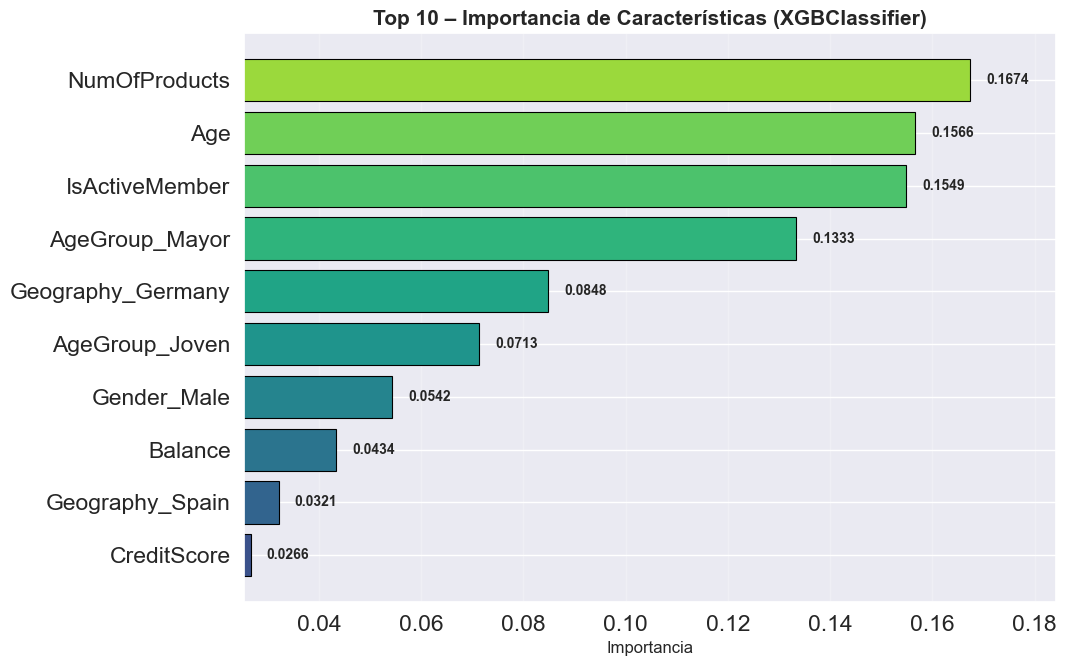

In [30]:
best_final_model = final_models[best_final_name]


# Elegimos el modelo para importancias
if isinstance(best_final_model, StackingClassifier):
    base_name = "xgb"  # seleccionamos la opcion del mejor modelo
    model_for_importance = best_final_model.named_estimators_[base_name]
else:
    model_for_importance = best_final_model

# Feature names alineados al input real
feature_names = list(X_train_processed.columns)

# Importancias (o fallback) segun el modelo seleccionado
if hasattr(model_for_importance, "feature_importances_"):
    importances = model_for_importance.feature_importances_
elif hasattr(model_for_importance, "coef_"):
    importances = np.abs(model_for_importance.coef_).ravel()
else:
    raise AttributeError("El modelo elegido no soporta feature_importances_ ni coef_.")

# Ordenamos el DataFrame
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Seleccionamos el top 10 features importantes
top_n = 10
top_features = fi_df.head(top_n).iloc[::-1]  # invertimos para barh

# Plot 
plt.figure(figsize=(11, 7))

palette = plt.cm.viridis(np.linspace(0.25, 0.85, top_n))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color=palette,
    edgecolor="black",
    linewidth=0.8
)

title_model = type(model_for_importance).__name__

plt.title(
    f"Top {top_n} – Importancia de Características ({title_model})",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importancia", fontsize=12)
plt.grid(True, axis="x", alpha=0.25)

# Padding dinámico eje X
xmin = top_features["Importance"].min() * 0.95
xmax = top_features["Importance"].max() * 1.10
plt.xlim(xmin, xmax)

# Etiquetas de valor al final de cada barra
for bar, value in zip(bars, top_features["Importance"]):
    plt.text(
        bar.get_width() + (xmax - xmin) * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 9. Conclusiones


**Conclusiones de las features con mayor importancia:**

- La cantidad de productos (*NumOfProducts*) es el factor más determinante del churn.
- La *edad* y los *grupos de edades* explican una parte sustancial del riesgo de abandono.
- La actividad del cliente (*IsActiveMember*) es un fuerte predictor de churn.
- Existen diferencias relevantes por *país*, especialmente en Alemania.
- El *balance*, el *género* y el *credit score* tienen un impacto menor en la predicción.

Implicación estratégica:
Las acciones de retención deberían centrarse en clientes con pocos productos, inactivos y pertenecientes a segmentos etarios y regiones de mayor riesgo.

**Conclusión sobre la comparacion de los modelos:**

El modelo Stacking supera al resto en la mayoría de las métricas relevantes, especialmente en ROC-AUC y Recall, lo que lo convierte en la mejor opción para un sistema de detección temprana de churn.

XGBoost optimizado con Optuna muestra un desempeño muy competitivo y destaca en PR-AUC, siendo una excelente alternativa más simple y eficiente computacionalmente.

CatBoost presenta el mejor F1-score, lo que lo posiciona como un modelo balanceado, aunque con menor capacidad de detección de churners que Stacking.

En un contexto de negocio donde el *objetivo es minimizar la pérdida de clientes*, se recomienda utilizar **Stacking como modelo final**, priorizando Recall sin sacrificar capacidad predictiva global.

